### **Libraries**

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import os

### **Classic Control Env**

In [49]:
folder = "/home/amina/projects/Advanced_Deep_Learning/homework/results/classic_env"

labels = {
    "REINFORCE_Pendulum-v1.csv": "REINFORCE",
    "A2C_separate_Pendulum-v1.csv": "A2C Separate",
    "A2C_shared_Pendulum-v1.csv": "A2C Shared",
    "A2C_shared_GAE_Pendulum-v1.csv": "A2C Shared + GAE"
}

data_dict = {}

In [50]:
for file in os.listdir(folder):
    if file.endswith(".csv"):
        path = os.path.join(folder, file)
        df = pd.read_csv(path)
        df["RollingAvg"] = df["reward"].rolling(window=50).mean() 
        data_dict[file] = df


Individual Reward Curves

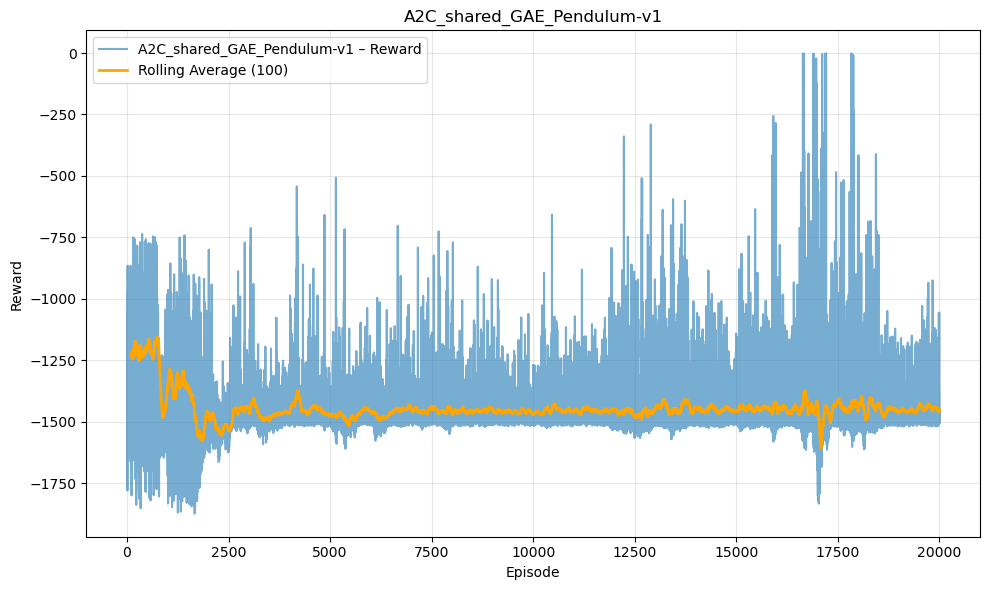

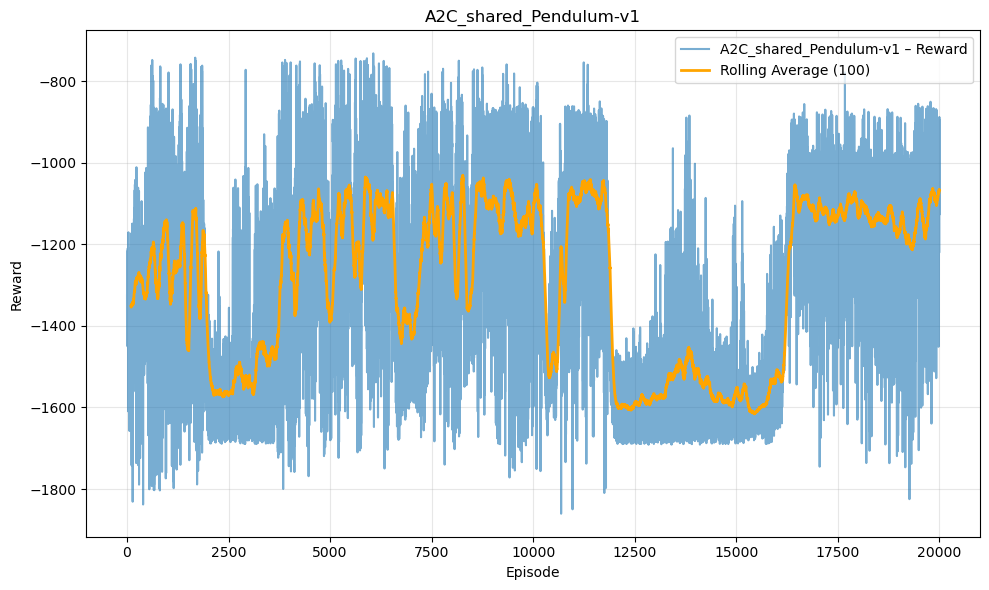

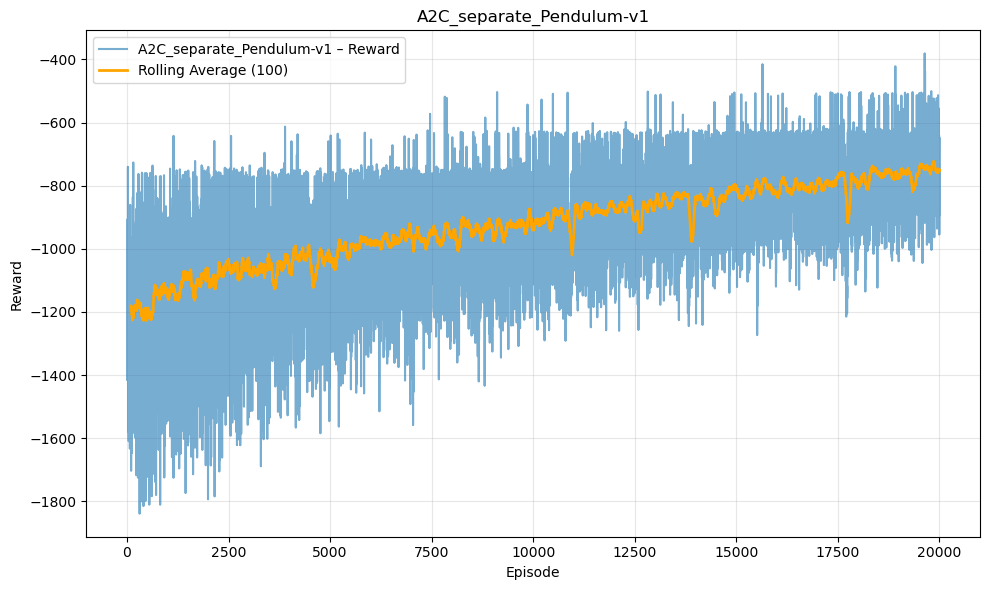

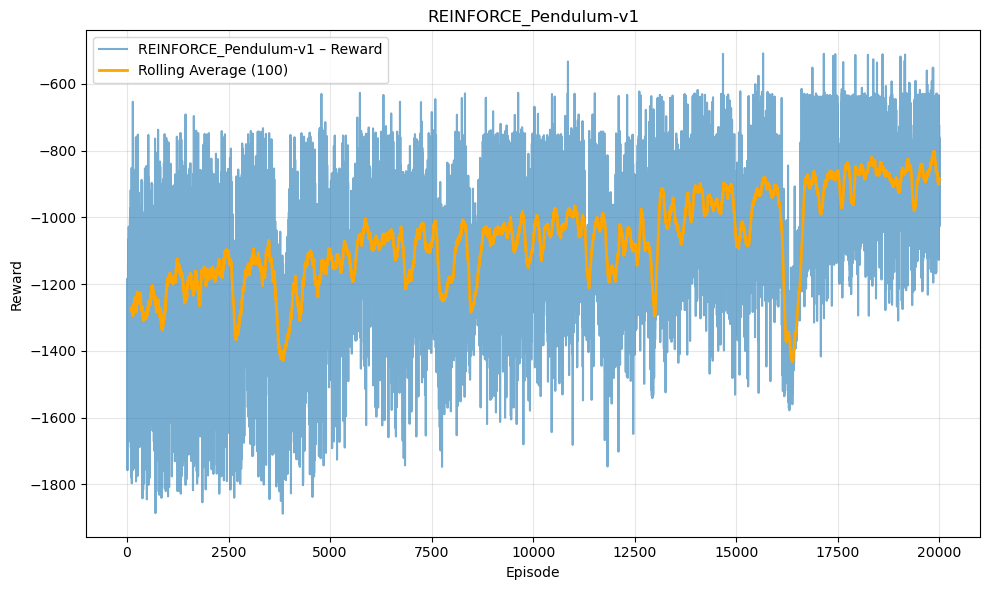

In [51]:
for file in os.listdir(folder):
    if file.endswith(".csv"):
        path = os.path.join(folder, file)
        name = file.replace(".csv", "")
        df = pd.read_csv(path)
        df["RollingAvg"] = df["reward"].rolling(window=100).mean()
        
        plt.figure(figsize=(10, 6))
        plt.plot(df["episode"], df["reward"], alpha=0.6, label=f"{name} – Reward")
        plt.plot(df["episode"], df["RollingAvg"], color="orange", linewidth=2, label="Rolling Average (100)")
        
        plt.title(name)
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

Comparison Curve

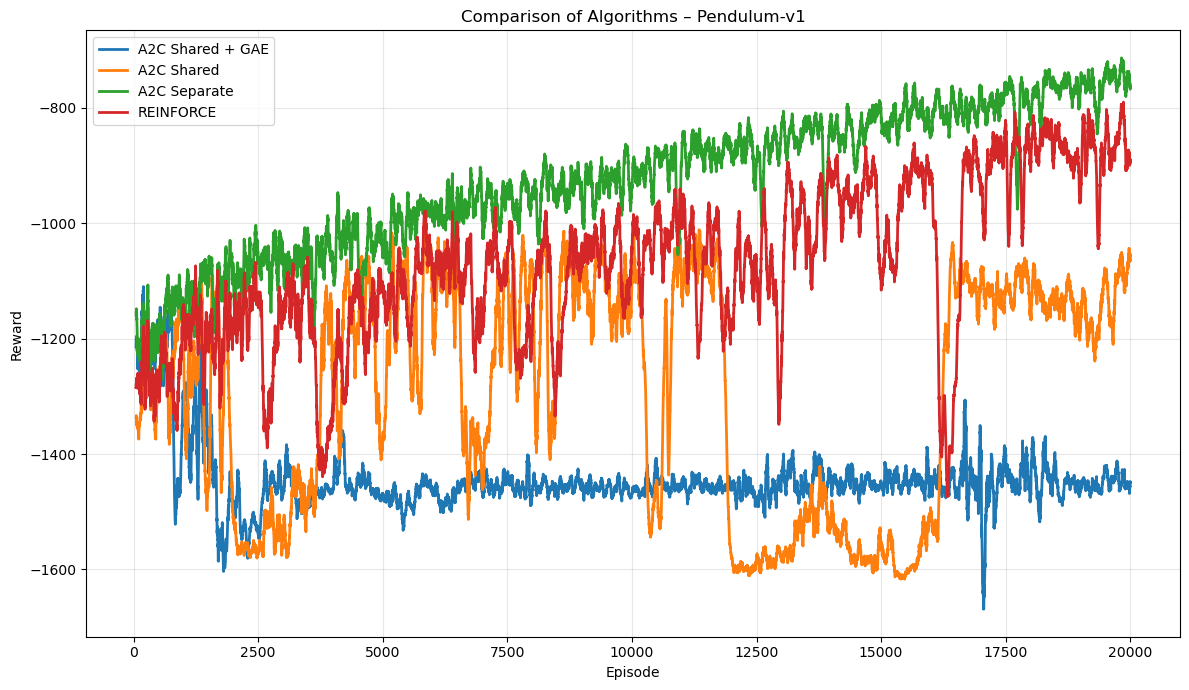

In [52]:
plt.figure(figsize=(12,7))
for file, df in data_dict.items():
    plt.plot(df["episode"], df["RollingAvg"], linewidth=2, label=labels[file])

plt.title("Comparison of Algorithms – Pendulum-v1")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Performance Table

In [53]:
metrics = []

for file, df in data_dict.items():
    avg_return = df["reward"].mean()
    std_return = df["reward"].std()
    threshold = df["RollingAvg"].quantile(0.8) 
    convergence_episode = df[df["RollingAvg"] >= threshold]["episode"].iloc[0]
    
    metrics.append({
        "Algorithm": labels[file],
        "Average Return": avg_return,
        "Std Return": std_return,
        "Convergence Episode": convergence_episode
    })

In [54]:
metrics_df = pd.DataFrame(metrics)
metrics_df

,Algorithm,Average Return,Std Return,Convergence Episode
0,A2C Shared + GAE,-1444.482009,139.598855,50
1,A2C Shared,-1289.330874,247.515767,1341
2,A2C Separate,-926.926247,184.063647,13039
3,REINFORCE,-1069.151997,219.634492,13106


### **Box2D Env**

In [55]:
folder = "/home/amina/projects/Advanced_Deep_Learning/homework/results/box2d_env"

labels = {
    "REINFORCE_LunarLanderContinuous-v2.csv": "REINFORCE",
    "A2C_separate_LunarLanderContinuous-v2.csv": "A2C Separate",
    "A2C_shared_LunarLanderContinuous-v2.csv": "A2C Shared",
    "A2C_shared_GAE_LunarLanderContinuous-v2.csv": "A2C Shared + GAE"
}

data_dict = {}

In [56]:
for file in os.listdir(folder):
    if file.endswith(".csv"):
        path = os.path.join(folder, file)
        df = pd.read_csv(path)
        df["RollingAvg"] = df["reward"].rolling(window=50).mean() 
        data_dict[file] = df

Individual Reward Curves

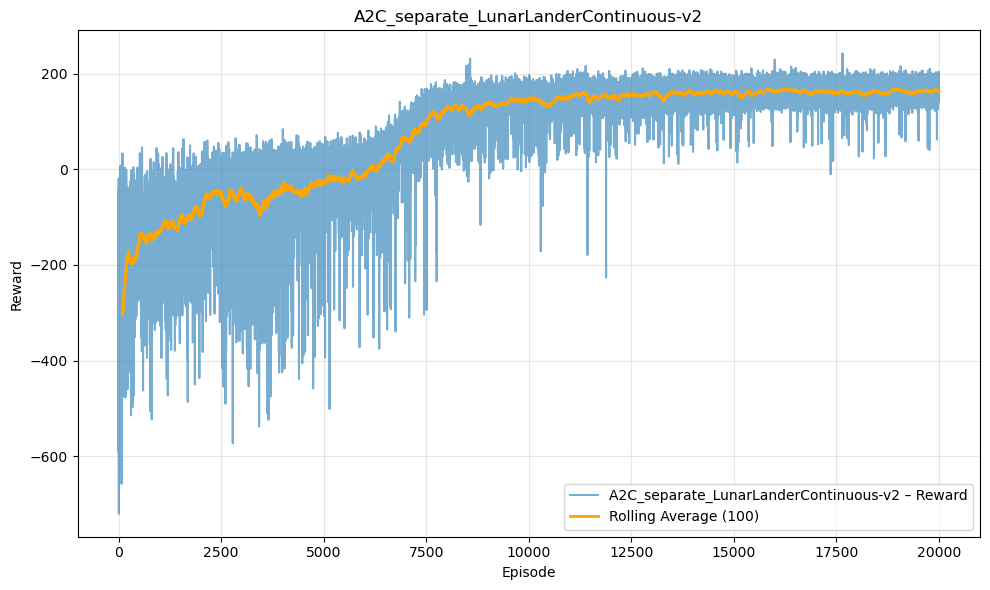

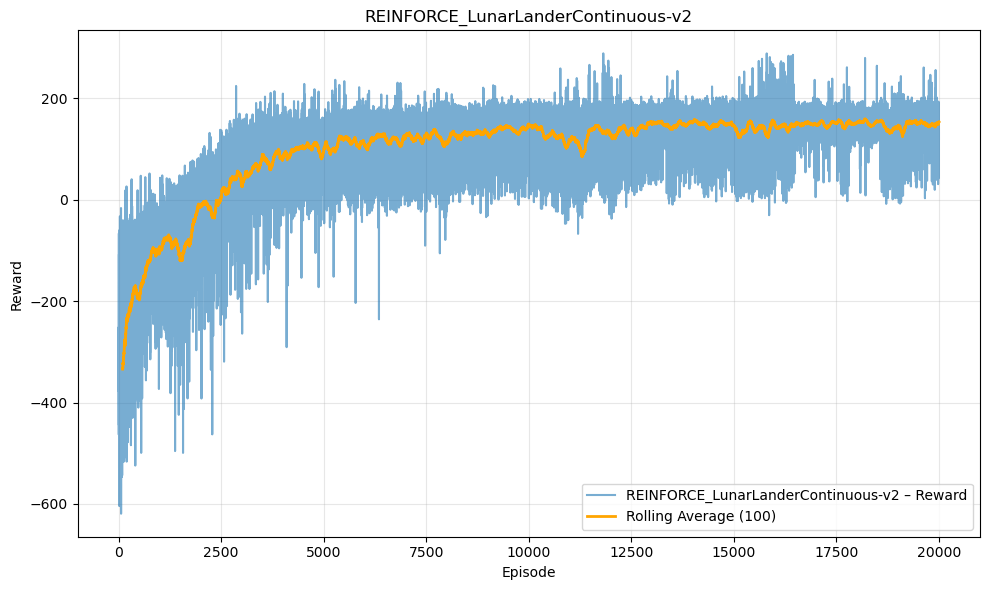

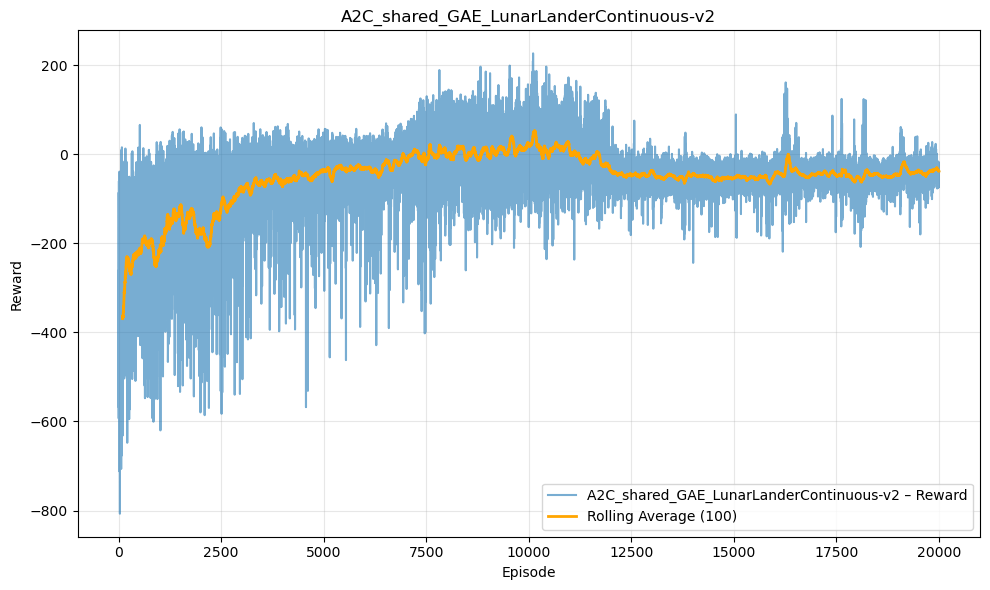

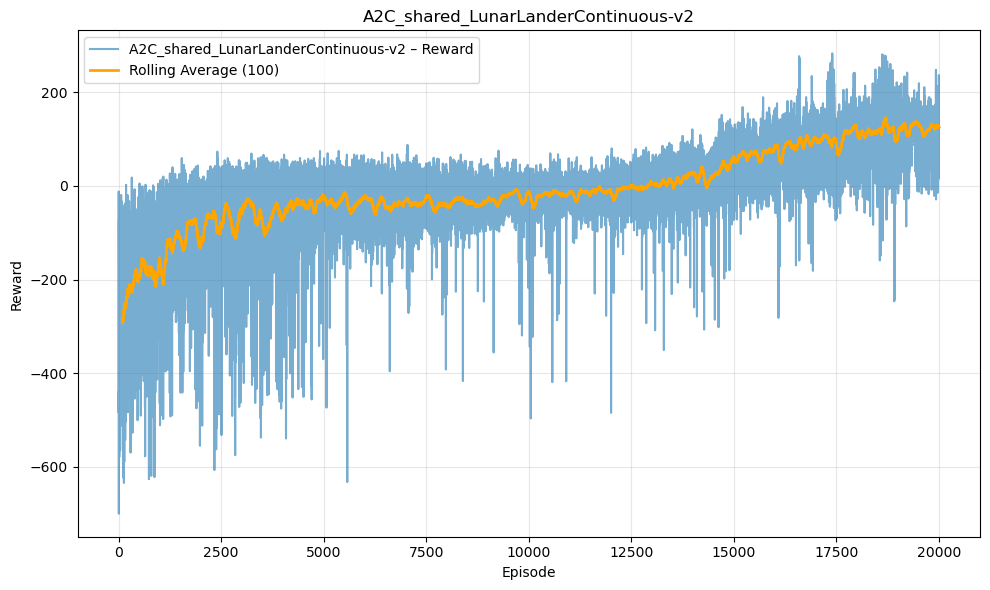

In [57]:
for file in os.listdir(folder):
    if file.endswith(".csv"):
        path = os.path.join(folder, file)
        name = file.replace(".csv", "")
        df = pd.read_csv(path)
        df["RollingAvg"] = df["reward"].rolling(window=100).mean()
        
        plt.figure(figsize=(10, 6))
        plt.plot(df["episode"], df["reward"], alpha=0.6, label=f"{name} – Reward")
        plt.plot(df["episode"], df["RollingAvg"], color="orange", linewidth=2, label="Rolling Average (100)")
        
        plt.title(name)
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

Comparison Curve

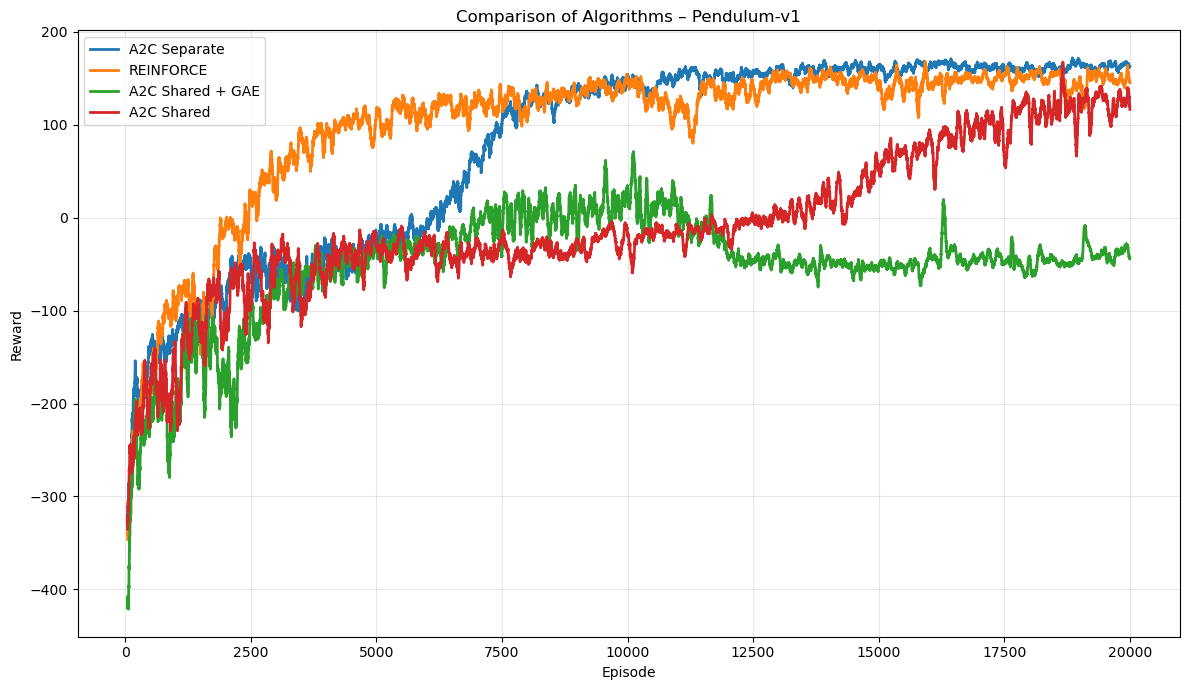

In [58]:
plt.figure(figsize=(12,7))
for file, df in data_dict.items():
    plt.plot(df["episode"], df["RollingAvg"], linewidth=2, label=labels[file])

plt.title("Comparison of Algorithms – Pendulum-v1")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Performance Table

In [59]:
metrics = []

for file, df in data_dict.items():
    avg_return = df["reward"].mean()
    std_return = df["reward"].std()
    threshold = df["RollingAvg"].quantile(0.8)  
    convergence_episode = df[df["RollingAvg"] >= threshold]["episode"].iloc[0]
    
    metrics.append({
        "Algorithm": labels[file],
        "Average Return": avg_return,
        "Std Return": std_return,
        "Convergence Episode": convergence_episode
    })

In [60]:
metrics_df = pd.DataFrame(metrics)
metrics_df

,Algorithm,Average Return,Std Return,Convergence Episode
0,A2C Separate,75.911674,120.417469,11146
1,REINFORCE,99.173492,101.143854,9226
2,A2C Shared + GAE,-52.268599,89.661670,6463
3,A2C Shared,-8.285235,102.844726,15221
